# Business Scenario
A multinational retail company wants an automated analytical solution to monitor sales, profitability, customer behavior, and operational performance.

# Detailed Required Tasks
• Import the dataset using Pandas and inspect the dataset structure and metadata.

• Perform advanced data cleaning including handling missing values, outliers, inconsistent formats, and duplicate records.

• Develop reusable preprocessing pipelines for cleaning and transforming the dataset.

• Create feature-engineered columns such as Profit Margin, Shipping Duration, and Sales Performance Category.

• Build modular Python functions for scalable analytical workflows.

• Perform advanced exploratory data analysis (EDA).

• Conduct statistical analysis including correlations, distributions, and trend analysis.

• Create advanced visualizations using Matplotlib and Seaborn.

• Generate automated KPI summaries and analytical reports.

• Export cleaned datasets and visual reports automatically.

• Optimize data frame operations and memory usage for performance.

----------------------------------------------------------------------------------------------------------------------------------------------

# Import Libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
from scipy import stats

# Data Loading & Initial Exploration

In [2]:
from pathlib import Path
file_path = Path(r"data\Sample - Superstore 2019.xls")
df = pd.read_excel(file_path, sheet_name="Orders")
raw_df = df.copy()

In [3]:
df.shape

(9994, 21)

In [4]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          9994 non-null   int64         
 1   Order ID        9994 non-null   object        
 2   Order Date      9994 non-null   datetime64[ns]
 3   Ship Date       9994 non-null   datetime64[ns]
 4   Ship Mode       9994 non-null   object        
 5   Customer ID     9994 non-null   object        
 6   Customer Name   9994 non-null   object        
 7   Segment         9994 non-null   object        
 8   Country/Region  9994 non-null   object        
 9   City            9994 non-null   object        
 10  State           9994 non-null   object        
 11  Postal Code     9983 non-null   float64       
 12  Region          9994 non-null   object        
 13  Product ID      9994 non-null   object        
 14  Category        9994 non-null   object        
 15  Sub-

In [6]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
Row ID,9994.0,4997.5,1.0,2499.25,4997.5,7495.75,9994.0,2885.163629
Order Date,9994,2018-04-30 10:03:51.979187712,2016-01-03 00:00:00,2017-05-23 00:00:00,2018-06-26 00:00:00,2019-05-14 00:00:00,2019-12-30 00:00:00,NaN
Ship Date,9994,2018-05-04 09:03:29.645787392,2016-01-07 00:00:00,2017-05-27 00:00:00,2018-06-29 00:00:00,2019-05-18 00:00:00,2020-01-05 00:00:00,NaN
Postal Code,9983.0,55245.233297,1040.0,23223.0,57103.0,90008.0,99301.0,32038.715955
Sales,9994.0,229.858001,0.444,17.28,54.49,209.94,22638.48,623.245101
Quantity,9994.0,3.789574,1.0,2.0,3.0,5.0,14.0,2.22511
Discount,9994.0,0.156203,0.0,0.0,0.2,0.2,0.8,0.206452
Profit,9994.0,28.656896,-6599.978,1.72875,8.6665,29.364,8399.976,234.260108


# Data Cleaning

In [7]:
missing_values = pd.DataFrame({'Missing_values': df.isna().sum().sort_values(ascending=False)})
missing_values

,Missing_values
Postal Code,11
Order ID,0
Order Date,0
Ship Date,0
Row ID,0
Ship Mode,0
Customer ID,0
Segment,0
Customer Name,0
Country/Region,0


In [8]:
df.isnull().sum().sort_values(ascending=False)

Postal Code       11
Order ID           0
Order Date         0
Ship Date          0
Row ID             0
Ship Mode          0
Customer ID        0
Segment            0
Customer Name      0
Country/Region     0
City               0
State              0
Region             0
Product ID         0
Category           0
Sub-Category       0
Product Name       0
Sales              0
Quantity           0
Discount           0
Profit             0
dtype: int64

In [9]:
df["Postal Code"] = df["Postal Code"].astype("Int64")

In [10]:
df["Order Date"] = pd.to_datetime(df["Order Date"])
df["Ship Date"] = pd.to_datetime(df["Ship Date"])

# Check data types
df.dtypes

Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID               object
Customer Name             object
Segment                   object
Country/Region            object
City                      object
State                     object
Postal Code                Int64
Region                    object
Product ID                object
Category                  object
Sub-Category              object
Product Name              object
Sales                    float64
Quantity                   int64
Discount                 float64
Profit                   float64
dtype: object

In [11]:
numeric_columns = ["Sales","Quantity","Discount","Profit"]

df[numeric_columns] = df[numeric_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

In [12]:
duplicate_values = df.duplicated().sum()
duplicate_values

np.int64(0)

In [13]:
categorical_columns = [
    "Ship Mode",
    "Segment",
    "Country/Region",
    "Region",
    "Category",
    "Sub-Category"
]

for col in categorical_columns:
    print(f"\n{col}")
    print(df[col].value_counts())


Ship Mode
Ship Mode
Standard Class    5968
Second Class      1945
First Class       1538
Same Day           543
Name: count, dtype: int64

Segment
Segment
Consumer       5191
Corporate      3020
Home Office    1783
Name: count, dtype: int64

Country/Region
Country/Region
United States    9994
Name: count, dtype: int64

Region
Region
West       3203
East       2848
Central    2323
South      1620
Name: count, dtype: int64

Category
Category
Office Supplies    6026
Furniture          2121
Technology         1847
Name: count, dtype: int64

Sub-Category
Sub-Category
Binders        1523
Paper          1370
Furnishings     957
Phones          889
Storage         846
Art             796
Accessories     775
Chairs          617
Appliances      466
Labels          364
Tables          319
Envelopes       254
Bookcases       228
Fasteners       217
Supplies        190
Machines        115
Copiers          68
Name: count, dtype: int64


In [14]:
# Check invalid numerical values

print("Negative Sales:", (df["Sales"] < 0).sum())
print("Invalid Quantity:", (df["Quantity"] <= 0).sum())
print(
    "Invalid Discount:",
    ((df["Discount"] < 0) | (df["Discount"] > 1)).sum()
)
print("Negative Profit:", (df["Profit"] < 0).sum())

Negative Sales: 0
Invalid Quantity: 0
Invalid Discount: 0
Negative Profit: 1871


# Data Quality Summary

In [15]:
unique_summary = pd.DataFrame({
    "Data Type": df.dtypes.astype(str),
    "Unique Values": df.nunique(),
    "Missing Values": df.isnull().sum()
})
unique_summary

,Data Type,Unique Values,Missing Values
Row ID,int64,9994,0
Order ID,object,5009,0
Order Date,datetime64[ns],1236,0
Ship Date,datetime64[ns],1334,0
Ship Mode,object,4,0
Customer ID,object,793,0
Customer Name,object,793,0
Segment,object,3,0
Country/Region,object,1,0
City,object,531,0


In [16]:
# Date Logic Validation
invalid_dates = df[
    df["Ship Date"] < df["Order Date"]
]

print(f"Invalid Date Records: {len(invalid_dates)}") 

Invalid Date Records: 0


Handling Outliers

In [17]:
for col in ["Sales", "Quantity", "Discount", "Profit"]:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    outliers = df[
        (df[col] < Q1 - 1.5 * IQR) |
        (df[col] > Q3 + 1.5 * IQR)
    ]
    
    print(f"{col}: {len(outliers):,} outliers")

Sales: 1,167 outliers
Quantity: 170 outliers
Discount: 856 outliers
Profit: 1,881 outliers


### Outlier Handling Decision

Outliers were detected using the IQR method.
They were not removed because statistical outliers are
not necessarily data errors. Extreme sales, discounts,
or profits may represent legitimate business transactions.

# Feature Engineering

In [18]:
df['Profit_Margin'] = (df['Profit'] / df['Sales']) * 100  # Profit Margin
df["Shipping_Duration"] = (df["Ship Date"] - df["Order Date"]).dt.days  # Shipping Duration

In [19]:
# Sales Performance Category (High , Medium , Low)
df["Sales Performance Category"] = pd.qcut(df["Sales"],q=3,labels=["Low", "Medium", "High"])
df["Sales Performance Category"].value_counts()

Sales Performance Category
High      3332
Low       3331
Medium    3331
Name: count, dtype: int64

In [20]:
# Date Features
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month
df['Month Name'] = df['Order Date'].dt.month_name()
df["Quarter"] = df["Order Date"].dt.quarter

In [21]:
# Check Our New Features
df.head(10)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Quantity,Discount,Profit,Profit_Margin,Shipping_Duration,Sales Performance Category,Year,Month,Month Name,Quarter
0,1,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2,0.00,41.9136,16.00,3,High,2018,11,November,4
1,2,CA-2018-152156,2018-11-08,2018-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,3,0.00,219.5820,30.00,3,High,2018,11,November,4
2,3,CA-2018-138688,2018-06-12,2018-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,0.00,6.8714,47.00,4,Low,2018,6,June,2
3,4,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,5,0.45,-383.0310,-40.00,7,High,2017,10,October,4
4,5,US-2017-108966,2017-10-11,2017-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2,0.20,2.5164,11.25,7,Low,2017,10,October,4
5,6,CA-2016-115812,2016-06-09,2016-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,7,0.00,14.1694,29.00,5,Medium,2016,6,June,2
6,7,CA-2016-115812,2016-06-09,2016-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,4,0.00,1.9656,27.00,5,Low,2016,6,June,2
7,8,CA-2016-115812,2016-06-09,2016-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,6,0.20,90.7152,10.00,5,High,2016,6,June,2
8,9,CA-2016-115812,2016-06-09,2016-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,3,0.20,5.7825,31.25,5,Low,2016,6,June,2
9,10,CA-2016-115812,2016-06-09,2016-06-14,Standard Class,BH-11710,Brosina Hoffman,Consumer,United States,Los Angeles,...,5,0.00,34.4700,30.00,5,Medium,2016,6,June,2


# Exploratory Data Analysis — EDA

In [22]:
# Overall Business KPIs

total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

print(f"Total Sales     : ${total_sales:,.2f}")
print(f"Total Profit    : ${total_profit:,.2f}")
print(f"Total Orders    : {total_orders:,}")
print(f"Total Customers : {total_customers:,}")

Total Sales     : $2,297,200.86
Total Profit    : $286,397.02
Total Orders    : 5,009
Total Customers : 793


In [23]:
avg_order_value = total_sales / total_orders
print(f"Average Order Value: ${avg_order_value:,.2f}")

Average Order Value: $458.61


Sales by Category

In [24]:
sales_by_category =(df.groupby('Category')['Sales'].sum().sort_values(ascending=False))
sales_by_category

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

Profit by Category

In [25]:
profit_by_category = ( df.groupby("Category")["Profit"].sum().sort_values(ascending=False))
profit_by_category

Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64

Category & Sub-Category Analysis (Sales & Profit)

In [26]:
sub_category_performance = (df.groupby(['Category','Sub-Category']).agg(Sales=('Sales','sum'), Profit=('Profit','sum')).sort_values(by=["Sales",'Profit'],ascending=False).round(2).reset_index())
sub_category_performance

,Category,Sub-Category,Sales,Profit
0,Technology,Phones,330007.05,44515.73
1,Furniture,Chairs,328449.10,26590.17
2,Office Supplies,Storage,223843.61,21278.83
3,Furniture,Tables,206965.53,-17725.48
4,Office Supplies,Binders,203412.73,30221.76
5,Technology,Machines,189238.63,3384.76
6,Technology,Accessories,167380.32,41936.64
7,Technology,Copiers,149528.03,55617.82
8,Furniture,Bookcases,114880.00,-3472.56
9,Office Supplies,Appliances,107532.16,18138.01


Sales & Profit by Region

In [27]:
region_performance = (
    df.groupby("Region").agg(Sales=("Sales", "sum"),Profit=("Profit", "sum"),Orders=("Order ID", "nunique")).sort_values("Sales", ascending=False))

region_performance

,Sales,Profit,Orders
Region,,,
West,725457.8245,108418.4489,1611
East,678781.2400,91522.7800,1401
Central,501239.8908,39706.3625,1175
South,391721.9050,46749.4303,822


States and Cities Analysis

In [28]:
state_and_city_performance = (df.groupby(['State','City']).agg(Sales=('Sales','sum'), Profit=('Profit','sum')).sort_values(by=["Sales",'Profit'],ascending=False).round(2).reset_index())
state_and_city_performance

,State,City,Sales,Profit
0,New York,New York City,256368.16,62036.98
1,California,Los Angeles,175851.34,30440.76
2,Washington,Seattle,119540.74,29156.10
3,California,San Francisco,112669.09,17507.39
4,Pennsylvania,Philadelphia,109077.01,-13837.77
...,...,...,...,...
599,Florida,Ormond Beach,2.81,-1.97
600,Florida,Pensacola,2.21,-1.48
601,Florida,Jupiter,2.06,0.15
602,Ohio,Elyria,1.82,-1.40


Product Analysis

In [29]:
# Top 10 products
top_product = (df.groupby('Product Name').agg(Sales=('Sales','sum'),Profit=('Profit','sum')).sort_values('Sales',ascending=False).round(2).head(10))
top_product

,Sales,Profit
Product Name,,
Canon imageCLASS 2200 Advanced Copier,61599.82,25199.93
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind,27453.38,7753.04
Cisco TelePresence System EX90 Videoconferencing Unit,22638.48,-1811.08
HON 5400 Series Task Chairs for Big and Tall,21870.58,0.00
GBC DocuBind TL300 Electric Binding System,19823.48,2233.51
GBC Ibimaster 500 Manual ProClick Binding System,19024.50,760.98
Hewlett Packard LaserJet 3310 Copier,18839.69,6983.88
"HP Designjet T520 Inkjet Large Format Printer - 24"" Color",18374.90,4094.98
GBC DocuBind P400 Electric Binding System,17965.07,-1878.17


Top 10 Customers

In [30]:
top_customers = (
    df.groupby("Customer Name")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum"),
        Orders=("Order ID", "nunique")
    )
    .sort_values("Sales", ascending=False)
    .head(10)
    .round(2)
)

top_customers

,Sales,Profit,Orders
Customer Name,,,
Sean Miller,25043.05,-1980.74,5
Tamara Chand,19052.22,8981.32,5
Raymond Buch,15117.34,6976.10,6
Tom Ashbrook,14595.62,4703.79,4
Adrian Barton,14473.57,5444.81,10
Ken Lonsdale,14175.23,806.85,12
Sanjit Chand,14142.33,5757.41,9
Hunter Lopez,12873.30,5622.43,6
Sanjit Engle,12209.44,2650.68,11


Shipping Analysis

In [31]:
# Avg shipping duration
average_shipping_duration = df["Shipping_Duration"].mean()

print(
    f"Average Shipping Duration: "
    f"{average_shipping_duration:.2f} days"
)

Average Shipping Duration: 3.96 days


In [32]:
# Shipping by Mode
shipping_analysis = (
    df.groupby("Ship Mode")
    .agg(
        Average_Shipping_Days=("Shipping_Duration", "mean"),
        Orders=("Order ID", "nunique")
    )
    .sort_values("Average_Shipping_Days")
)

shipping_analysis

,Average_Shipping_Days,Orders
Ship Mode,,
Same Day,0.044199,264
First Class,2.182705,787
Second Class,3.237532,964
Standard Class,5.006535,2994


Time Trend Analysis

In [33]:
# Sales by Years
yearly_sales = (df.groupby(['Year','Quarter'])['Sales'].sum().round(2).reset_index())
yearly_sales

,Year,Quarter,Sales
0,2016,1,74447.80
1,2016,2,86538.76
2,2016,3,143633.21
3,2016,4,179627.73
4,2017,1,68851.74
5,2017,2,89124.19
6,2017,3,130259.58
7,2017,4,182297.01
8,2018,1,93237.18
9,2018,2,136082.30


Profit by Year

In [34]:
yearly_profit = (df.groupby("Year")["Profit"].sum())

yearly_profit

Year
2016    49543.9741
2017    61618.6037
2018    81795.1743
2019    93439.2696
Name: Profit, dtype: float64

In [35]:
# Monthly Sales
monthly_sales = (
    df.groupby(["Year", "Month"])["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Year,Month,Sales
0,2016,1,14236.895
1,2016,2,4519.892
2,2016,3,55691.009
3,2016,4,28295.345
4,2016,5,23648.287


# Statistical Analysis


In [36]:
# Distribution Statistics
df[["Sales","Profit", "Quantity","Discount","Profit_Margin","Shipping_Duration"]].describe().T

,count,mean,std,min,25%,50%,75%,max
Sales,9994.0,229.858001,623.245101,0.444,17.28000,54.4900,209.940,22638.480
Profit,9994.0,28.656896,234.260108,-6599.978,1.72875,8.6665,29.364,8399.976
Quantity,9994.0,3.789574,2.225110,1.000,2.00000,3.0000,5.000,14.000
Discount,9994.0,0.156203,0.206452,0.000,0.00000,0.2000,0.200,0.800
Profit_Margin,9994.0,12.031393,46.675435,-275.000,7.50000,27.0000,36.250,50.000
Shipping_Duration,9994.0,3.958075,1.747937,0.000,3.00000,4.0000,5.000,7.000


In [37]:
# Correlation Matrix
corr_matrix = df[["Sales","Profit", "Quantity","Discount","Profit_Margin","Shipping_Duration"]].corr().round(2)
corr_matrix

,Sales,Profit,Quantity,Discount,Profit_Margin,Shipping_Duration
Sales,1.00,0.48,0.20,-0.03,0.00,-0.01
Profit,0.48,1.00,0.07,-0.22,0.22,-0.00
Quantity,0.20,0.07,1.00,0.01,-0.01,0.02
Discount,-0.03,-0.22,0.01,1.00,-0.86,0.00
Profit_Margin,0.00,0.22,-0.01,-0.86,1.00,-0.01
Shipping_Duration,-0.01,-0.00,0.02,0.00,-0.01,1.00


In [38]:
# CREATE OUTPUT DIRECTORIES
from pathlib import Path

output_dir = Path("outputs")
visual_dir = output_dir / "visualizations"

output_dir.mkdir(exist_ok=True)
visual_dir.mkdir(exist_ok=True)

print("Output directories are ready.")
print(f"Output directory: {output_dir.resolve()}")

Output directories are ready.
Output directory: D:\DEPI\Mini-Project 1 — Advanced Python Data Exploration & Automated Reporting\outputs


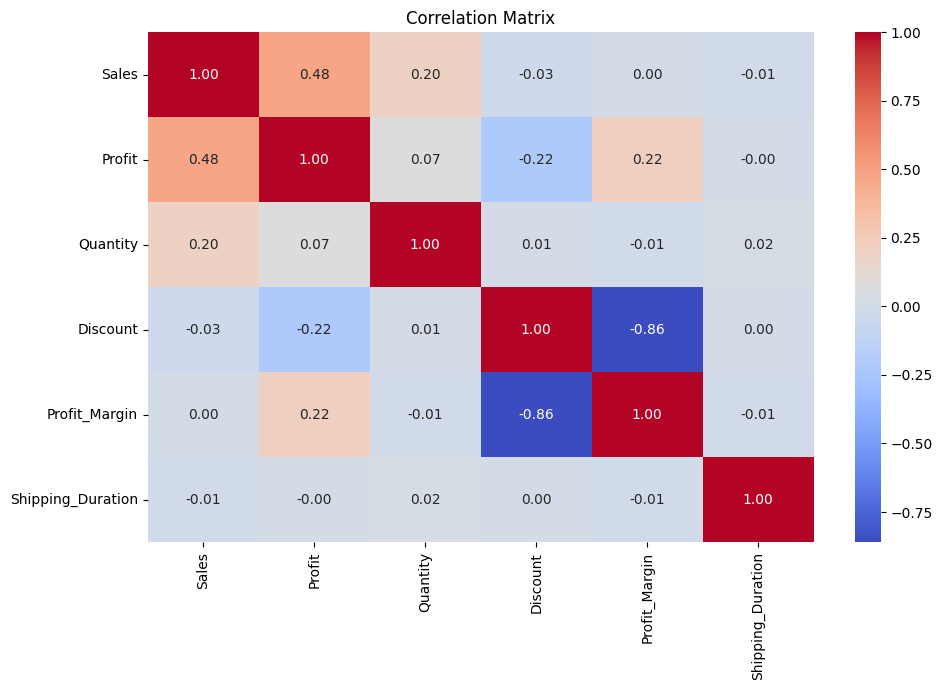

In [39]:
# Correlation Visualization
plt.figure(figsize=(10, 7))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig(
    visual_dir / "correlation.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Advanced Visualizations

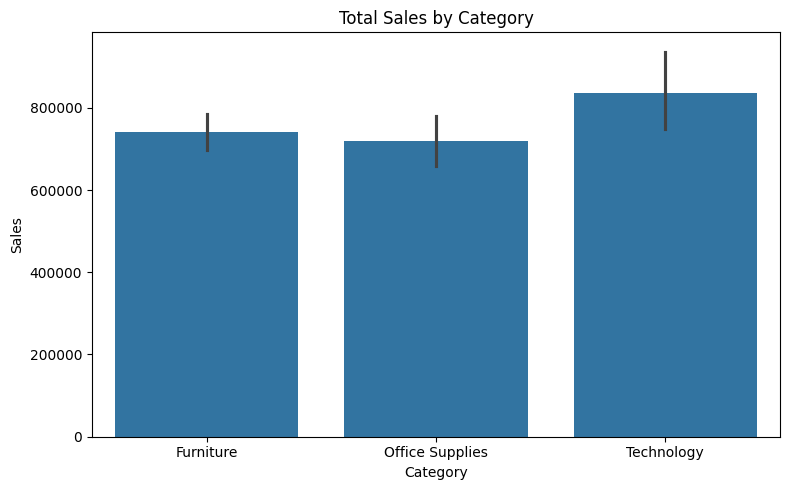

In [40]:
# Sales by Category
plt.figure(figsize=(8, 5))

sns.barplot(
    data=df,
    x="Category",
    y="Sales",
    estimator="sum"
)

plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.tight_layout()
plt.savefig(
    visual_dir / "sales by Category.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Sales Trend

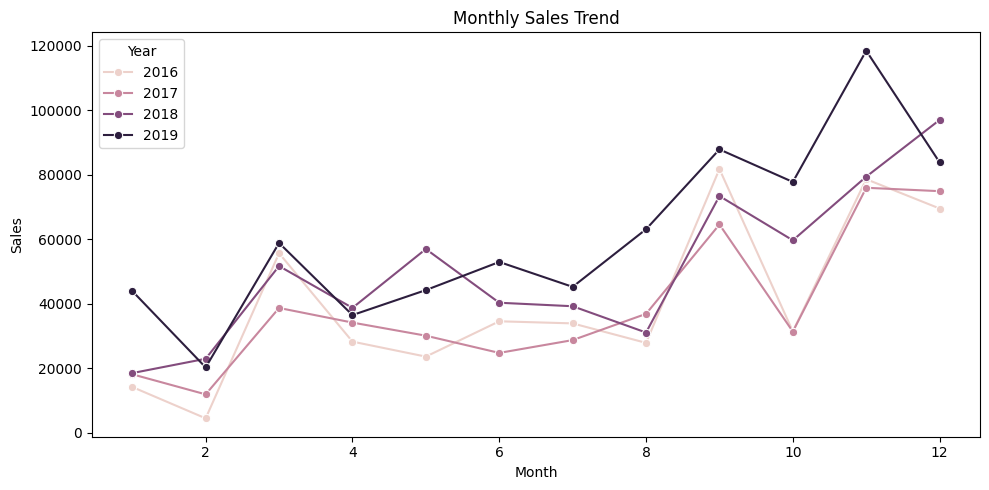

In [41]:
plt.figure(figsize=(10, 5))

sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Sales",
    hue="Year",
    marker="o"
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.tight_layout()
plt.savefig(
    visual_dir / "sales Trend.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Sales vs Profit

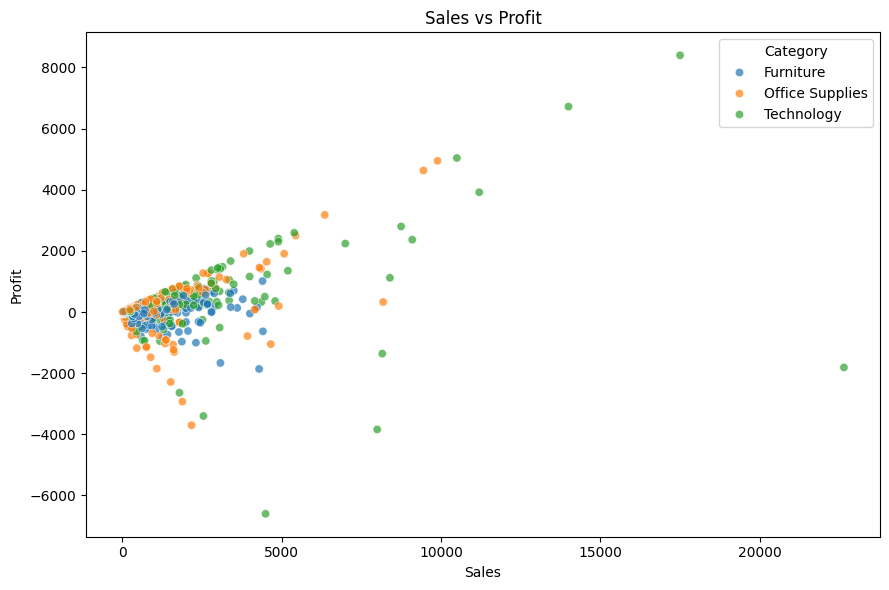

In [42]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Sales",
    y="Profit",
    hue="Category",
    alpha=0.7
)

plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")

plt.tight_layout()
plt.savefig(
    visual_dir / "sales vs profit.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Regional Performance

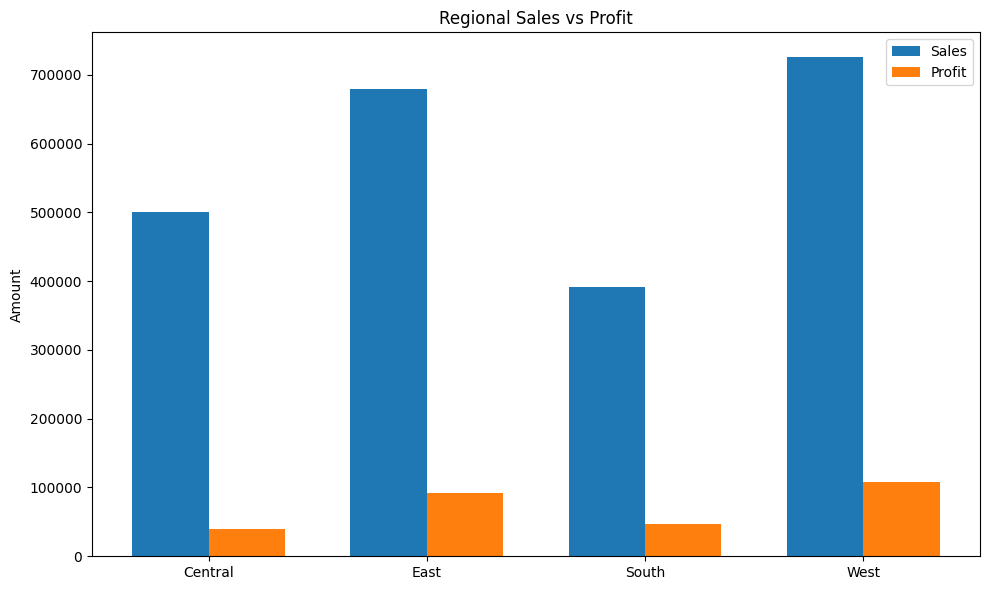

In [43]:
region_plot = (
    df.groupby("Region")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(region_plot))
width = 0.35

ax.bar(
    x - width / 2,
    region_plot["Sales"],
    width,
    label="Sales"
)

ax.bar(
    x + width / 2,
    region_plot["Profit"],
    width,
    label="Profit"
)

ax.set_xticks(x)
ax.set_xticklabels(region_plot["Region"])

ax.set_title("Regional Sales vs Profit")
ax.set_ylabel("Amount")
ax.legend()

plt.tight_layout()
plt.savefig(
    visual_dir / "Regional Sales vs Profit.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Top 10 Products

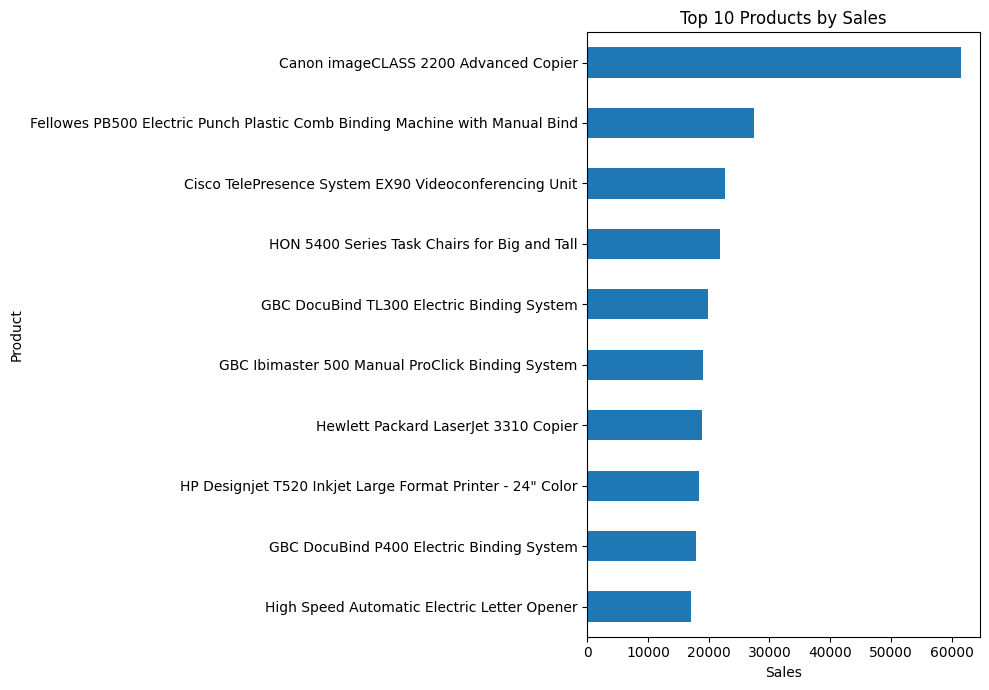

In [44]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .sort_values()
)

plt.figure(figsize=(10, 7))

top_products.plot(kind="barh")

plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.ylabel("Product")

plt.tight_layout()
plt.savefig(
    visual_dir / "Top 10 Products.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Discount vs Profit

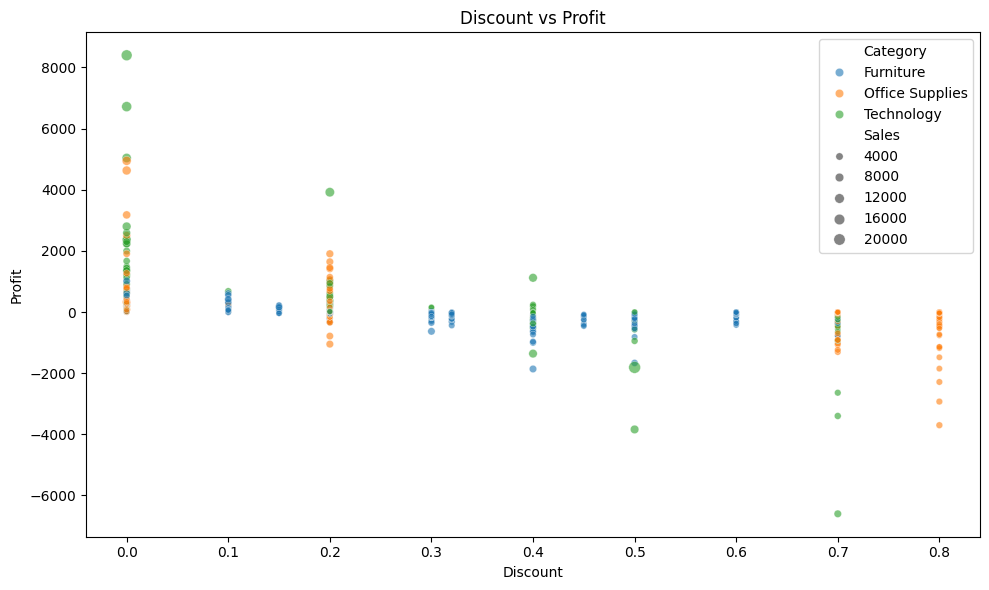

In [45]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="Discount",
    y="Profit",
    size="Sales",
    hue="Category",
    alpha=0.6
)

plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")

plt.tight_layout()
plt.savefig(
    visual_dir / "Discount vs Profit.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Category Profitability

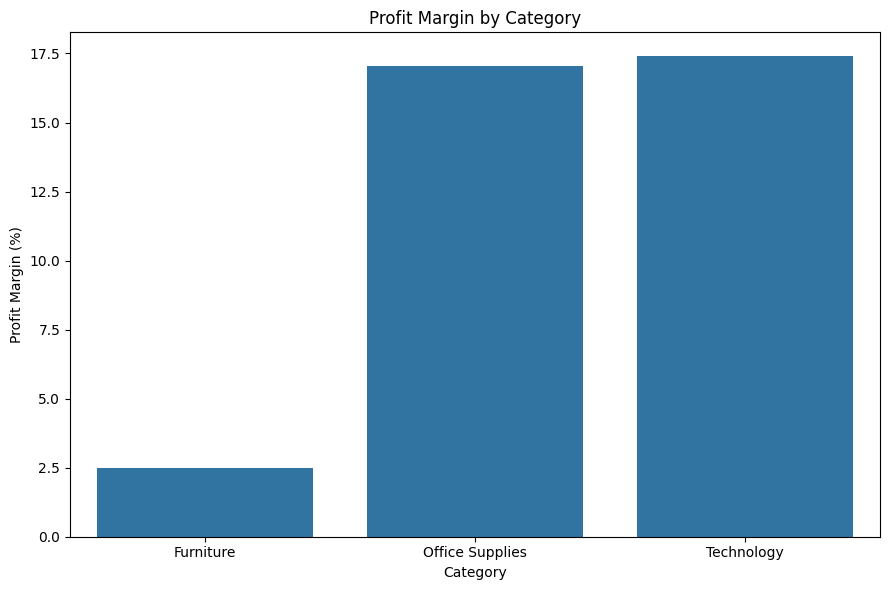

In [46]:
category_profitability = (
    df.groupby("Category")
    .agg(
        Sales=("Sales", "sum"),
        Profit=("Profit", "sum")
    )
    .reset_index()
)

category_profitability["Profit Margin"] = (
    category_profitability["Profit"] /
    category_profitability["Sales"] * 100
)

plt.figure(figsize=(9, 6))

sns.barplot(
    data=category_profitability,
    x="Category",
    y="Profit Margin"
)

plt.title("Profit Margin by Category")
plt.xlabel("Category")
plt.ylabel("Profit Margin (%)")

plt.tight_layout()
plt.savefig(
    visual_dir / "Profit Margin by Category.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Automated KPI Summary


In [47]:
def generate_kpi_summary(data):
    
    total_sales = data["Sales"].sum()
    total_profit = data["Profit"].sum()
    total_orders = data["Order ID"].nunique()
    total_customers = data["Customer ID"].nunique()
    
    overall_profit_margin = (
        total_profit / total_sales
    ) * 100
    
    average_order_value = (
        total_sales / total_orders
    )
    
    average_shipping_days = (
        data["Shipping_Duration"].mean()
    )
    
    return pd.DataFrame({
        "KPI": [
            "Total Sales",
            "Total Profit",
            "Total Orders",
            "Total Customers",
            "Overall Profit Margin",
            "Average Order Value",
            "Average Shipping Duration"
        ],
        
        "Value": [
            total_sales,
            total_profit,
            total_orders,
            total_customers,
            overall_profit_margin,
            average_order_value,
            average_shipping_days
        ]
    })
kpi_summary = generate_kpi_summary(df).round(2)

kpi_summary

,KPI,Value
0,Total Sales,2297200.86
1,Total Profit,286397.02
2,Total Orders,5009.00
3,Total Customers,793.00
4,Overall Profit Margin,12.47
5,Average Order Value,458.61
6,Average Shipping Duration,3.96


## Reusable Preprocessing Functions

In [48]:
def clean_data(data):
    data = data.copy()

    # Convert date columns
    data["Order Date"] = pd.to_datetime(data["Order Date"])
    data["Ship Date"] = pd.to_datetime(data["Ship Date"])

    # Convert numerical columns
    numeric_columns = [
        "Sales",
        "Quantity",
        "Discount",
        "Profit"
    ]

    data[numeric_columns] = data[numeric_columns].apply(
        pd.to_numeric,
        errors="coerce"
    )

    # Keep missing Postal Codes without creating false values
    data["Postal Code"] = data["Postal Code"].astype("Int64")

    return data

def create_features(data):
    data = data.copy()

    # Profit Margin
    data["Profit_Margin"] = np.where(
        data["Sales"] != 0,
        (data["Profit"] / data["Sales"]) * 100,
        0
    )

    # Shipping Duration
    data["Shipping_Duration"] = (
        data["Ship Date"] - data["Order Date"]
    ).dt.days

    # Sales Performance Category
    data["Sales Performance Category"] = pd.qcut(
        data["Sales"],
        q=3,
        labels=["Low", "Medium", "High"]
    )

    # Date Features
    data["Year"] = data["Order Date"].dt.year
    data["Month"] = data["Order Date"].dt.month
    data["Month Name"] = data["Order Date"].dt.month_name()
    data["Quarter"] = data["Order Date"].dt.quarter

    return data

Outlier Analysis Function (reusable)

In [49]:
def detect_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]

    return len(outliers)

outlier_summary = pd.DataFrame({
    "Column": ["Sales", "Quantity", "Discount", "Profit"],
    "Outliers": [
        detect_outliers(df, "Sales"),
        detect_outliers(df, "Quantity"),
        detect_outliers(df, "Discount"),
        detect_outliers(df, "Profit")
    ]
})

outlier_summary

,Column,Outliers
0,Sales,1167
1,Quantity,170
2,Discount,856
3,Profit,1881


##  Automatic Export

Export Cleaned Dataset

In [50]:
df.to_csv(
    output_dir / "cleaned_superstore.csv",
    index=False
)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.


Export KPI Summary

In [51]:
kpi_summary.to_csv(
    output_dir / "kpi_summary.csv",
    index=False
)

print("KPI summary exported successfully.")

KPI summary exported successfully.


Analytical Tables

In [52]:
region_performance.to_csv(
    output_dir / "region_performance.csv",
    index=False
)

top_customers.to_csv(
    output_dir / "top_customers.csv",
    index=False
)

top_products.to_csv(
    output_dir / "top_products.csv",
    index=False
)

yearly_sales.to_csv(
    output_dir / "yearly_sales.csv",
    index=False
)

yearly_profit.to_csv(
    output_dir / "yearly_profit.csv",
    index=False
)
monthly_sales.to_csv(
    output_dir / "monthly_sales.csv",
    index=False
)

category_profitability.to_csv(
    output_dir / "category_profitability.csv",
    index=False
)

shipping_analysis.to_csv(
    output_dir / "shipping_analysis.csv",
    index=True
)

print("Analytical tables exported successfully.")

Analytical tables exported successfully.


# Automated Analytical Report

In [53]:
best_region = region_performance["Profit"].idxmax()

best_category = category_profitability.loc[
    category_profitability["Profit"].idxmax(),
    "Category"
]

best_product = top_product["Sales"].idxmax()

best_customer = top_customers["Sales"].idxmax()

discount_profit_correlation = (
    df["Discount"].corr(df["Profit"])
)

sales_profit_correlation = (
    df["Sales"].corr(df["Profit"])
)

## 10. Memory Optimization

Memory usage was evaluated before and after optimizing categorical columns.
Categorical data types were used to reduce unnecessary memory consumption.

In [54]:
memory_before = df.memory_usage(deep=True).sum()

print(
    f"Memory Before Optimization: "
    f"{memory_before / 1024**2:.2f} MB"
)

Memory Before Optimization: 9.08 MB


In [55]:
categorical_columns = [
    "Ship Mode",
    "Segment",
    "Country/Region",
    "Region",
    "Category",
    "Sub-Category"
]

for column in categorical_columns:
    df[column] = df[column].astype("category")

In [56]:
# MEMORY USAGE AFTER OPTIMIZATION
# ============================================

memory_after = df.memory_usage(deep=True).sum()

memory_reduction = (
    (memory_before - memory_after)
    / memory_before
) * 100

print(
    f"Memory After Optimization: "
    f"{memory_after / 1024**2:.2f} MB"
)

print(
    f"Memory Reduction: "
    f"{memory_reduction:.2f}%"
)

Memory After Optimization: 5.78 MB
Memory Reduction: 36.43%


# Generate Report

In [57]:
total_sales = df["Sales"].sum()
total_profit = df["Profit"].sum()
total_orders = df["Order ID"].nunique()
total_customers = df["Customer ID"].nunique()

overall_profit_margin = (
    total_profit / total_sales
) * 100

average_order_value = (
    total_sales / total_orders
)

average_shipping_days = (
    df["Shipping_Duration"].mean()
)

report = f"""
SUPERSTORE BUSINESS ANALYTICAL REPORT
=====================================

1. EXECUTIVE KPIs
-----------------
Total Sales: ${total_sales:,.2f}
Total Profit: ${total_profit:,.2f}
Total Orders: {total_orders:,}
Total Customers: {total_customers:,}
Overall Profit Margin: {overall_profit_margin:.2f}%
Average Order Value: ${average_order_value:,.2f}
Average Shipping Duration: {average_shipping_days:.2f} days


2. PERFORMANCE HIGHLIGHTS
-------------------------
Best Region by Profit: {best_region}
Best Category by Profit: {best_category}
Top Product by Sales: {best_product}
Top Customer by Sales: {best_customer}


3. STATISTICAL INSIGHTS
-----------------------
Sales-Profit Correlation: {sales_profit_correlation:.2f}
Discount-Profit Correlation: {discount_profit_correlation:.2f}


4. OUTLIER SUMMARY
------------------
Sales Outliers: {detect_outliers(df, "Sales"):,}
Quantity Outliers: {detect_outliers(df, "Quantity"):,}
Discount Outliers: {detect_outliers(df, "Discount"):,}
Profit Outliers: {detect_outliers(df, "Profit"):,}


5. BUSINESS INTERPRETATION
--------------------------
The analysis evaluates sales, profitability, customer behavior,
product performance, regional performance, shipping operations,
discount impact, and time-based trends.

Statistical outliers were identified for investigation but were
not automatically removed because an outlier does not necessarily
represent a data quality error.

Higher discount levels show a negative association with profit
in the analyzed dataset. This relationship should be interpreted
as an association rather than a causal relationship.

High sales performance does not always indicate high profitability.
Therefore, both revenue and profit should be considered when
evaluating customers, products, categories, and regions.
"""

print(report)


SUPERSTORE BUSINESS ANALYTICAL REPORT

1. EXECUTIVE KPIs
-----------------
Total Sales: $2,297,200.86
Total Profit: $286,397.02
Total Orders: 5,009
Total Customers: 793
Overall Profit Margin: 12.47%
Average Order Value: $458.61
Average Shipping Duration: 3.96 days


2. PERFORMANCE HIGHLIGHTS
-------------------------
Best Region by Profit: West
Best Category by Profit: Technology
Top Product by Sales: Canon imageCLASS 2200 Advanced Copier
Top Customer by Sales: Sean Miller


3. STATISTICAL INSIGHTS
-----------------------
Sales-Profit Correlation: 0.48
Discount-Profit Correlation: -0.22


4. OUTLIER SUMMARY
------------------
Sales Outliers: 1,167
Quantity Outliers: 170
Discount Outliers: 856
Profit Outliers: 1,881


5. BUSINESS INTERPRETATION
--------------------------
The analysis evaluates sales, profitability, customer behavior,
product performance, regional performance, shipping operations,
discount impact, and time-based trends.

Statistical outliers were identified for investig

### Export Business Report

In [58]:
report_path = output_dir / "superstore_business_report.txt"

with open(
    report_path,
    "w",
    encoding="utf-8"
) as file:
    file.write(report)

print(f"Business report saved to: {report_path.resolve()}")

Business report saved to: D:\DEPI\Mini-Project 1 — Advanced Python Data Exploration & Automated Reporting\outputs\superstore_business_report.txt
